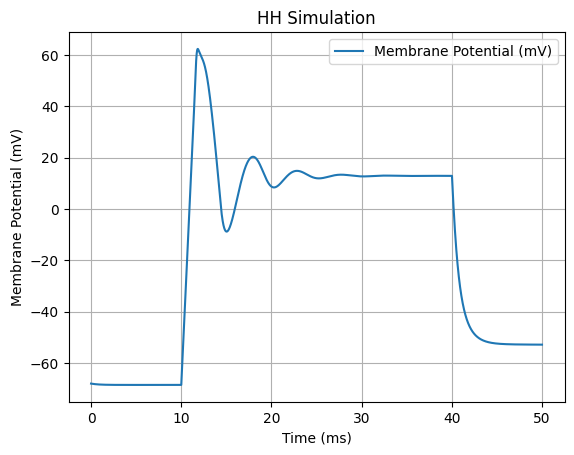

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Initial resting and Nernst potentials
E_0 = -68 # -68 mV
E_Na = 54.2 # 54.2 mV
E_K = -74.7 # -74.7 mV
E_L = -65.8 # -65.8 mV

# initial activation and inactivation parameters
n_0 = 0.3
m_0 = 0.0665
h_0 = 0.6

# initial / maximal conductances
G_K = 12 # 12 mmho
G_Na = 30 # 30 mmho
G_l = 0.001 # 0.001 mmho

C_m = 1 # 1 uF/cm^2

# time step and total time
dt = 0.01 # 0.01 ms
T_total = 50 # 50 ms

t = np.arange(0, T_total, dt) # time array
V = np.zeros_like(t) # voltage array
n = np.zeros_like(t) # n array
m = np.zeros_like(t) # m array
h = np.zeros_like(t) # h array

# Set initial conditions
V[0], n[0], m[0], h[0] = E_0, n_0, m_0, h_0

# Defining the alpha and beta functions for n, m, and h
def alpha_n(V):
    return 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)

def beta_n(V):
    return 0.125 * np.exp(-(V) / 80)

def alpha_m(V):
    return 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)

def beta_m(V):
    return 4.0 * np.exp(-(V) / 18)

def alpha_h(V):
    return 0.07 * np.exp(-(V) / 20)

def beta_h(V):
    return 1 / (1 + np.exp((30 - V) / 10))

def dn_dt(n, V):
    return alpha_n(V) * (1 - n) - beta_n(V) * n

def dm_dt(m, V):
    return alpha_m(V) * (1 - m) - beta_m(V) * m

def dh_dt(h, V):
    return alpha_h(V) * (1 - h) - beta_h(V) * h

def g_K(n):
    return G_K * n**4

def g_Na(m, h):
    return G_Na * m**3 * h

def g_L():
    return G_l

def I_K(V, n):
    return g_K(n) * (V - E_K)

def I_Na(V, m, h):
    return g_Na(m, h) * (V - E_Na)

def I_L(V):
    return g_L() * (V - E_L)

def I_ext(t):
    return  75 if 10 <= t <= 40 else 0

def dV_dt(V, n, m, h, t):
    I_total = - I_K(V, n) - I_Na(V, m, h) - I_L(V) + I_ext(t)
    return I_total / C_m

# now we can make up the derivative functions for V, n, m, and h

def derivatives(V, n, m, h, t):
    return dV_dt(V, n, m, h, t), dn_dt(n, V), dm_dt(m, V), dh_dt(h, V)

# Euler method for numerical integration (in-place)
for i in range(1, len(t)):
    dV, dn, dm, dh = derivatives(V[i-1], n[i-1], m[i-1], h[i-1], t[i-1])
    V[i] = V[i-1] + dV * dt
    n[i] = n[i-1] + dn * dt
    m[i] = m[i-1] + dm * dt
    h[i] = h[i-1] + dh * dt

# Plotting the results
plt.plot(t, V, label='Membrane Potential (mV)')
plt.title('HH Simulation')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()
plt.show()


[-68.         -68.01295898 -68.02055625 ...  21.88228383  21.88293501
  21.88358611]


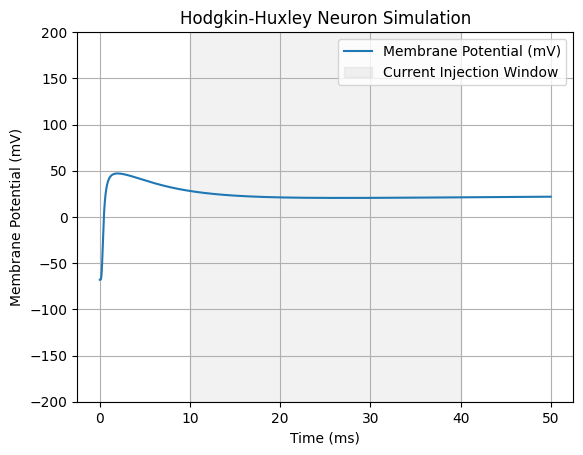

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initial resting and Nernst potentials (Absolute values)
E_0 = -68.0   # -68 mV
E_Na = 54.2   # 54.2 mV
E_K = -74.7   # -74.7 mV
E_L = -65.8   # -65.8 mV

# Initial activation and inactivation parameters
n_0 = 0.3
m_0 = 0.0665
h_0 = 0.6

# Maximal conductances
G_K = 12.0     # 12 mho/cm^2
G_Na = 30.0    # 30 mho/cm^2
G_l = 0.001    # 0.001 mho/cm^2

C_m = 1.0      # 1 uF/cm^2

# Time step and total time
dt = 0.01      # 0.01 ms
T_total = 5.0 # 50 ms

t = np.arange(0, T_total, dt)
V = np.zeros_like(t)
n = np.zeros_like(t)
m = np.zeros_like(t)
h = np.zeros_like(t)

# Set initial conditions
V[0], n[0], m[0], h[0] = E_0, n_0, m_0, h_0

# Defining alpha and beta functions adjusted for absolute voltage V
# We subtract E_0 to convert absolute voltage to the HH relative voltage baseline.
def alpha_n(V):
    v_rel = V - E_0
    denom = np.exp(-(10 - v_rel) / 10) - 1
    # Handle division by zero singularity smoothly
    return np.where(np.abs(10 - v_rel) < 1e-6, 0.1, 0.01 * (10 - v_rel) / denom)

def beta_n(V):
    v_rel = V - E_0
    return 0.125 * np.exp(-v_rel / 80)

def alpha_m(V):
    v_rel = V - E_0
    denom = np.exp(-(25 - v_rel) / 10) - 1
    # Handle division by zero singularity smoothly
    return np.where(np.abs(25 - v_rel) < 1e-6, 1.0, 0.1 * (25 - v_rel) / denom)

def beta_m(V):
    v_rel = V - E_0
    return 4 * np.exp(-v_rel / 18)

def alpha_h(V):
    v_rel = V - E_0
    return 0.07 * np.exp(-v_rel / 20)

def beta_h(V):
    v_rel = V - E_0
    return 1 / (1 + np.exp((30 - v_rel) / 10))

# Derivatives
def dn_dt(n, V):
    return alpha_n(V) * (1 - n) - beta_n(V) * n

def dm_dt(m, V):
    return alpha_m(V) * (1 - m) - beta_m(V) * m

def dh_dt(h, V):
    return alpha_h(V) * (1 - h) - beta_h(V) * h

# Currents
def I_ion(V, n, m, h):
    I_K = G_K * (n**4) * (V - E_K)
    I_Na = G_Na * (m**3) * h * (V - E_Na)
    I_L = G_l * (V - E_L)
    return I_Na - I_K - I_L


def I_ext(t):
    return 0

def dV_dt(V, n, m, h, t):
    # Fixed formula sign: External current depolarizes, Ionic currents hyperpolarize
    return -(I_ext(t) - I_ion(V, n, m, h)) / C_m

def derivatives(V, n, m, h, t):
    return dV_dt(V, n, m, h, t), dn_dt(n, V), dm_dt(m, V), dh_dt(h, V)

# Euler method for numerical integration
for i in range(1, len(t)):
    dV, dn, dm, dh = derivatives(V[i-1], n[i-1], m[i-1], h[i-1], t[i-1])
    V[i] = V[i-1] + dV * dt
    n[i] = n[i-1] + dn * dt
    m[i] = m[i-1] + dm * dt
    h[i] = h[i-1] + dh * dt


print(V)
# Plotting the results
plt.plot(t, V, label='Membrane Potential (mV)')
plt.title('Hodgkin-Huxley Neuron Simulation')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.ylim(-200, 200)
plt.axvspan(10, 40, color='gray', alpha=0.1, label='Current Injection Window')
plt.legend()
plt.grid(True)
plt.show()